# 多策略回测（0.3.0）

```bash
# git clone https://github.com/myang682/stockportfoliotoolkit
cd stockportfoliotoolkit
pip install -e .
```

本篇把 MOM / STR / WSTR 三路 alpha 一次性喂进流水线，横向比较。单信号入门见
[quickstart_mom.ipynb](quickstart_mom.ipynb)。

0.2.0 相对 0.1.0，有以下不同：

- 修复一些 bug
- 参考 PEP 规范优化代码结构，自定义方法/类全部使用官方 ABC 写法，方便扩展
- 可自行配置 benchmark 线
- 多信号时**分位图按信号拆成多张**，对比图仍然叠在一起

0.3.0 相对 0.2.0：

- 不再内置 S&P 500 标准数据，也不再自动叠加该基准线。基准改由 `input.references`
  声明，使用者自备数据，详见第 7 节
- `charts[].show_benchmark` 随之移除。配置中写该字段会报 `ConfigError`

In [1]:
import stockportfoliotoolkit as spt

spt.__version__

'0.2.0'

## 1 数据

一张全量美股日频面板。工具包只要 `date / id / close / cap` 四列，其余列随你放着。

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.feather as feather

# 价格面板位置。设环境变量 SPT_PRICES 指向本机实际文件即可，无需改动本 notebook。
PRICES = os.environ.get(
    "SPT_PRICES", "/path/to/stock_rag_cache/processed/processed_stock_data.feather"
)

feather.read_table(PRICES, memory_map=True).schema.names[:16]

['date',
 'id',
 'siccd',
 'close',
 'cap',
 'ret',
 'vol',
 'low',
 'high',
 'open',
 'shares',
 'market_cap',
 'label',
 'log_ret',
 'cum_log_ret',
 'ewma_vol']

In [3]:
feather.read_table(
    PRICES, columns=["date", "id", "close", "cap", "cum_log_ret"], memory_map=True
).slice(0, 5).to_pandas()

,date,id,close,cap,cum_log_ret
0,1992-01-02,10001,14.500,15587.50,0.0000
1,1992-01-03,10001,14.500,15587.50,0.0000
2,1992-01-06,10001,14.500,15587.50,0.0000
3,1992-01-07,10001,14.500,15587.50,0.0000
4,1992-01-08,10001,15.125,16259.38,0.0422


## 2 三路 alpha

本包只消费 alpha，不生成信号。

In [4]:
%%time
HORIZON = 5          # 前视收益跨多少个交易日
STRIDE = 5           # 调仓间隔，与 HORIZON 一致才不会重叠
FIRST = "2021-01-04"

panel = feather.read_table(
    PRICES, columns=["date", "id", "close", "cum_log_ret"], memory_map=True
).to_pandas().sort_values(["id", "date"], kind="stable", ignore_index=True)

g = panel.groupby("id", sort=False)
close = panel["close"]

alphas = {
    "MOM": g["close"].shift(21) / g["close"].shift(252) - 1.0,
    "STR": -(close / g["close"].shift(21) - 1.0),
    "WSTR": -(close / g["close"].shift(5) - 1.0),
}
fwd_ret = np.exp(g["cum_log_ret"].shift(-HORIZON) - panel["cum_log_ret"]) - 1.0

days = pd.DatetimeIndex(np.unique(panel["date"].to_numpy()))
anchors = set(days[days >= FIRST][::STRIDE])

base = panel[["date", "id"]].assign(fwd_ret=fwd_ret.to_numpy())
signals = {
    name: (
        base.assign(alpha=series.to_numpy())
        .query("date in @anchors")
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["alpha"])
        .sort_values(["date", "id"], kind="stable", ignore_index=True)
    )
    for name, series in alphas.items()
}
del panel, alphas, fwd_ret, g, close, base

pd.DataFrame({
    name: {
        "行数": len(df),
        "调仓日": df["date"].nunique(),
        "股票数": df["id"].nunique(),
        "alpha 均值": round(df["alpha"].mean(), 4),
        "alpha 标准差": round(df["alpha"].std(), 4),
    }
    for name, df in signals.items()
}).T

CPU times: user 12 s, sys: 6.5 s, total: 18.5 s
Wall time: 15.3 s


,行数,调仓日,股票数,alpha 均值,alpha 标准差
MOM,1211662.0,251.0,6786.0,0.3714,4.6757
STR,1320237.0,251.0,7385.0,-0.0640,2.4065
WSTR,1328053.0,251.0,7449.0,-0.0184,1.2939


In [5]:
# 信号表长这样：一行一个 (调仓日, 股票)，alpha 是打分，fwd_ret 是实现收益
signals["MOM"].head()

,date,id,fwd_ret,alpha
0,2021-01-04,10026,0.005321,-0.231237
1,2021-01-04,10028,0.120623,2.021429
2,2021-01-04,10032,0.081269,-0.020332
3,2021-01-04,10044,0.102439,-0.523864
4,2021-01-04,10051,0.051826,-0.141912


In [6]:
# 产物写入目录。设环境变量 SPT_WORK 指向本机缓存根目录即可。
WORK = Path(os.environ.get("SPT_WORK", "/path/to/portfolio_tool_cache")) / "multi_signal"
WORK.mkdir(parents=True, exist_ok=True)
for name, df in signals.items():
    df.to_feather(WORK / f"signal_{name.lower()}.feather")

sorted(p.name for p in WORK.glob("signal_*.feather"))

['signal_mom.feather', 'signal_str.feather', 'signal_wstr.feather']

## 3 四个模块分别配置

每个模块一份 JSON。多策略的关键只有一处：**`input.signals` 是列表，一项就是一路策略**，
`name` 会成为结果表里的 `signal_model`。

如果几路 alpha 在**同一个文件的不同列**里，写法一样——多项 spec 指向同一个 `path`，
各自的 `column_map.alpha` 填各自的列名。

In [ ]:
import json

CONFIGS = WORK / "configs"
CONFIGS.mkdir(exist_ok=True)

# output_dir 留空 → 产物落到信号文件同级的 outputs/
OUT = WORK / "outputs"

configs = {
    "input.json": {
        "vars": {"SIG": str(WORK)},
        "prices": {
            "path": PRICES,
            "column_map": {"date": "date", "id": "id", "close": "close", "cap": "cap"},
            "restrict_to_signal_assets": True,
        },
        # 三个策略
        "signals": [
            {
                "name": name,
                "path": f"${{SIG}}/signal_{name.lower()}.feather",
                "column_map": {
                    "date": "date", "id": "id", "alpha": "alpha", "fwd_ret": "fwd_ret",
                },
            }
            for name in ("MOM", "STR", "WSTR")
        ],
        "calendar": {"first_rebalance": FIRST, "rebalance_freq": STRIDE},
    },
    "engine.json": {
        "n_buckets": 10,
        "min_names": 20,
        "weights": ["ew", "vw"],
        # horizon 必填。holding_days 不写 = 继承它
        "forward_return": {"horizon": HORIZON, "source": "signals"},
    },
    "analyzer.json": {
        "metrics": [
            "ann_ret", "ann_vol", "sharpe", "max_drawdown", "total_equity", "hit_rate",
        ],
    },
    "visualizer.json": {
        "charts": [
            # 策略对比图：三路信号叠一张
            {"name": "long_short", "buckets": ["H-L"], "show_baseline": True},
            # 分位图：gradient → 每路信号单独一张
            {
                "name": "decile_spread",
                "buckets": [str(i) for i in range(10)] + ["H-L"],
                "color_mode": "gradient",
                "legend_ncol": 2,
            },
        ],
        "tables": [
            {"name": "metrics_by_bucket", "type": "summary"},
            {"name": "ic_by_period", "type": "ic"},
        ],
    },
}
for filename, payload in configs.items():
    (CONFIGS / filename).write_text(json.dumps(payload, indent=2), encoding="utf-8")

print(json.dumps(configs["input.json"]["signals"], indent=2))

[
  {
    "name": "MOM",
    "path": "${SIG}/signal_mom.feather",
    "column_map": {
      "date": "date",
      "id": "id",
      "alpha": "alpha",
      "fwd_ret": "fwd_ret"
    }
  },
  {
    "name": "STR",
    "path": "${SIG}/signal_str.feather",
    "column_map": {
      "date": "date",
      "id": "id",
      "alpha": "alpha",
      "fwd_ret": "fwd_ret"
    }
  },
  {
    "name": "WSTR",
    "path": "${SIG}/signal_wstr.feather",
    "column_map": {
      "date": "date",
      "id": "id",
      "alpha": "alpha",
      "fwd_ret": "fwd_ret"
    }
  }
]


## 4 跑

In [8]:
%%time
from stockportfoliotoolkit import run_pipeline

result = run_pipeline(CONFIGS)

CPU times: user 24.3 s, sys: 6.85 s, total: 31.1 s
Wall time: 28.5 s


## 5 结果

In [9]:
print(json.dumps(result.bundle.meta, indent=2, ensure_ascii=False))

{
  "signals": {
    "MOM": {
      "rows": 1211662,
      "assets": 6786,
      "first": "2021-01-04",
      "last": "2025-12-24",
      "rows_on_calendar": 1211662,
      "source_rows": 1211662,
      "source_na_rate": 0.0
    },
    "STR": {
      "rows": 1320237,
      "assets": 7385,
      "first": "2021-01-04",
      "last": "2025-12-24",
      "rows_on_calendar": 1320237,
      "source_rows": 1320237,
      "source_na_rate": 0.0
    },
    "WSTR": {
      "rows": 1328053,
      "assets": 7449,
      "first": "2021-01-04",
      "last": "2025-12-24",
      "rows_on_calendar": 1328053,
      "source_rows": 1328053,
      "source_na_rate": 0.0
    }
  },
  "prices": {
    "rows": 6656698,
    "assets": 7449,
    "first": "2021-01-04",
    "last": "2025-12-31"
  },
  "references": [],
  "calendar": {
    "periods": 251,
    "first": "2021-01-04",
    "last": "2025-12-24",
    "rebalance_freq": 5,
    "native_stride": 5,
    "applied_stride": 1
  }
}


In [10]:
# 逐期组合收益长表：signal_model 区分策略，bucket 区分分位
result.engine.returns.head()

,date,signal_model,bucket,weight,ret,count
0,2021-01-04,MOM,0,EW,0.111624,445
1,2021-01-11,MOM,0,EW,0.062962,446
2,2021-01-19,MOM,0,EW,0.019532,446
3,2021-01-26,MOM,0,EW,0.047095,450
4,2021-02-02,MOM,0,EW,0.092982,435


In [11]:
summary = result.analysis.summary
print("列  :", list(summary.columns))
print("行数:", len(summary),
      "=", summary["signal_model"].nunique(), "信号",
      "×", summary["bucket"].nunique(), "桶",
      "×", summary["weight"].nunique(), "加权")
summary.head()

列  : ['signal_model', 'bucket', 'weight', 'n_periods', 'ann_ret', 'ann_vol', 'sharpe', 'max_drawdown', 'total_equity', 'hit_rate', 'turnover', 'ic_mean']
行数: 66 = 3 信号 × 11 桶 × 2 加权


,signal_model,bucket,weight,n_periods,ann_ret,ann_vol,sharpe,max_drawdown,total_equity,hit_rate,turnover,ic_mean
0,MOM,0,EW,250,-0.077212,0.330839,-0.233382,-0.802255,0.519490,0.508,0.284802,0.029098
1,MOM,1,EW,250,0.033694,0.259933,0.129624,-0.540714,0.998876,0.520,0.434463,0.029098
2,MOM,2,EW,250,0.080908,0.207435,0.390038,-0.338436,1.341886,0.548,0.531693,0.029098
3,MOM,3,EW,250,0.093769,0.172347,0.544067,-0.261821,1.478184,0.544,0.594216,0.029098
4,MOM,4,EW,250,0.090262,0.150173,0.601051,-0.247054,1.478983,0.556,0.625427,0.029098


In [12]:
# 三路策略的多空腿横向对比 —— 多信号配置最直接的用处
summary[summary["bucket"] == "H-L"].round(4)

,signal_model,bucket,weight,n_periods,ann_ret,ann_vol,sharpe,max_drawdown,total_equity,hit_rate,turnover,ic_mean
10,MOM,H-L,EW,250,0.0923,0.2153,0.4288,-0.4202,1.4060,0.572,0.2648,0.0291
21,MOM,H-L,VW,250,0.1714,0.3024,0.5670,-0.3767,1.8676,0.528,0.2648,0.0291
32,STR,H-L,EW,250,0.1383,0.1874,0.7377,-0.2120,1.8208,0.512,0.5768,0.0023
43,STR,H-L,VW,250,-0.1437,0.2998,-0.4792,-0.6866,0.3918,0.488,0.5768,0.0023
54,WSTR,H-L,EW,250,0.3156,0.1758,1.7950,-0.1564,4.4170,0.588,0.7891,0.0240
65,WSTR,H-L,VW,250,0.0270,0.2973,0.0907,-0.4773,0.9207,0.492,0.7891,0.0240


In [13]:
# 分位单调性：等权口径下每路策略的十分位年化收益
ew = summary[(summary["weight"] == "EW") & (summary["bucket"] != "H-L")]
ew.pivot(index="bucket", columns="signal_model", values="ann_ret").reindex(
    [str(i) for i in range(10)]
).round(4)

signal_model,MOM,STR,WSTR
bucket,,,
0,-0.0772,-0.0990,-0.2011
1,0.0337,0.0451,-0.0053
2,0.0809,0.0676,0.0404
3,0.0938,0.0714,0.0282
4,0.0903,0.0767,0.0778
5,0.1006,0.0936,0.1364
6,0.0990,0.1173,0.1245
7,0.1164,0.0921,0.1264
8,0.1145,0.0479,0.1157


In [14]:
# IC 与换手也是逐信号独立算的
ic = result.analysis.ic.groupby("signal_model")["ic"].agg(["mean", "std", "count"])
turnover = (
    result.analysis.turnover.query("bucket == 'H-L'")
    .groupby("signal_model")["turnover"].mean().rename("turnover")
)
ic.join(turnover).round(4)

,mean,std,count,turnover
signal_model,,,,
MOM,0.0291,0.1409,250,0.2648
STR,0.0023,0.1262,250,0.5768
WSTR,0.0240,0.1295,250,0.7891


## 6 图

In [15]:
for path in sorted(p.name for p in result.outputs if p.suffix == ".png"):
    print(" ", path)

  decile_spread_mom_ew.png
  decile_spread_mom_vw.png
  decile_spread_str_ew.png
  decile_spread_str_vw.png
  decile_spread_wstr_ew.png
  decile_spread_wstr_vw.png
  long_short_ew.png
  long_short_vw.png


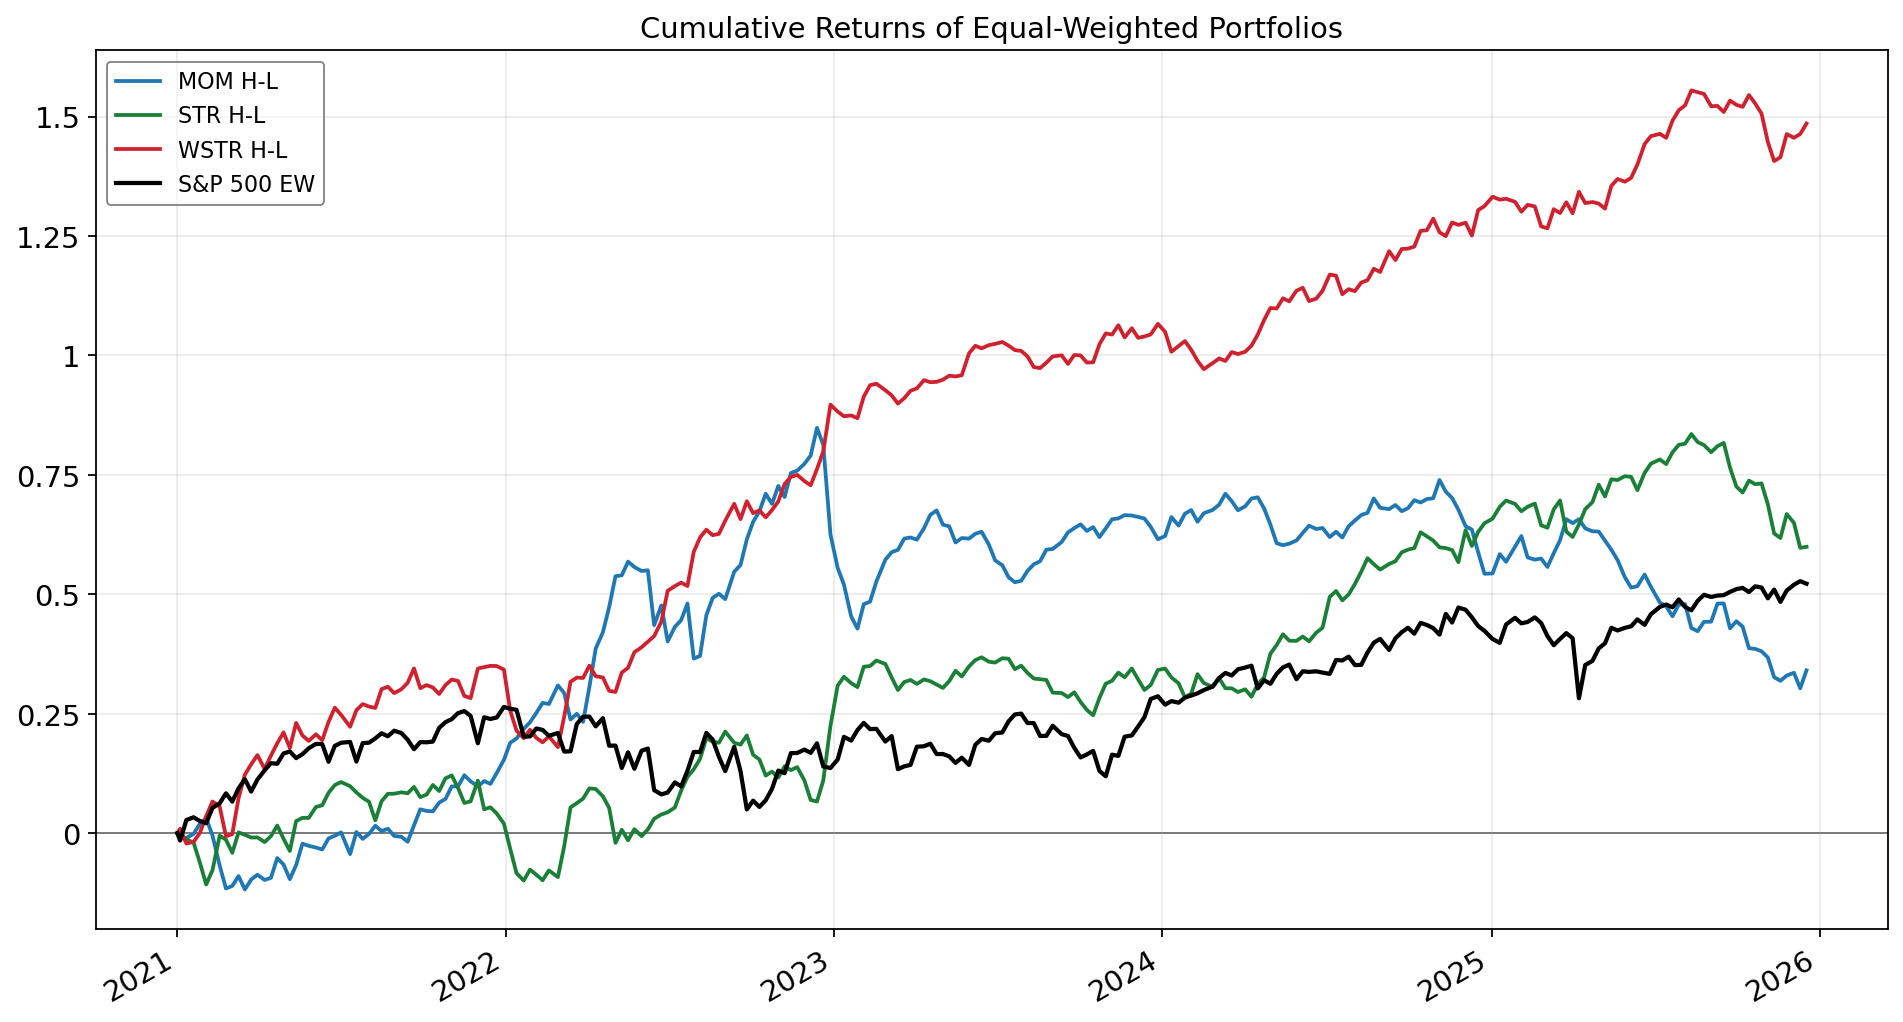

In [16]:
from IPython.display import Image, display

# 对比图：三路策略同图
display(Image(str(OUT / "long_short_ew.png")))


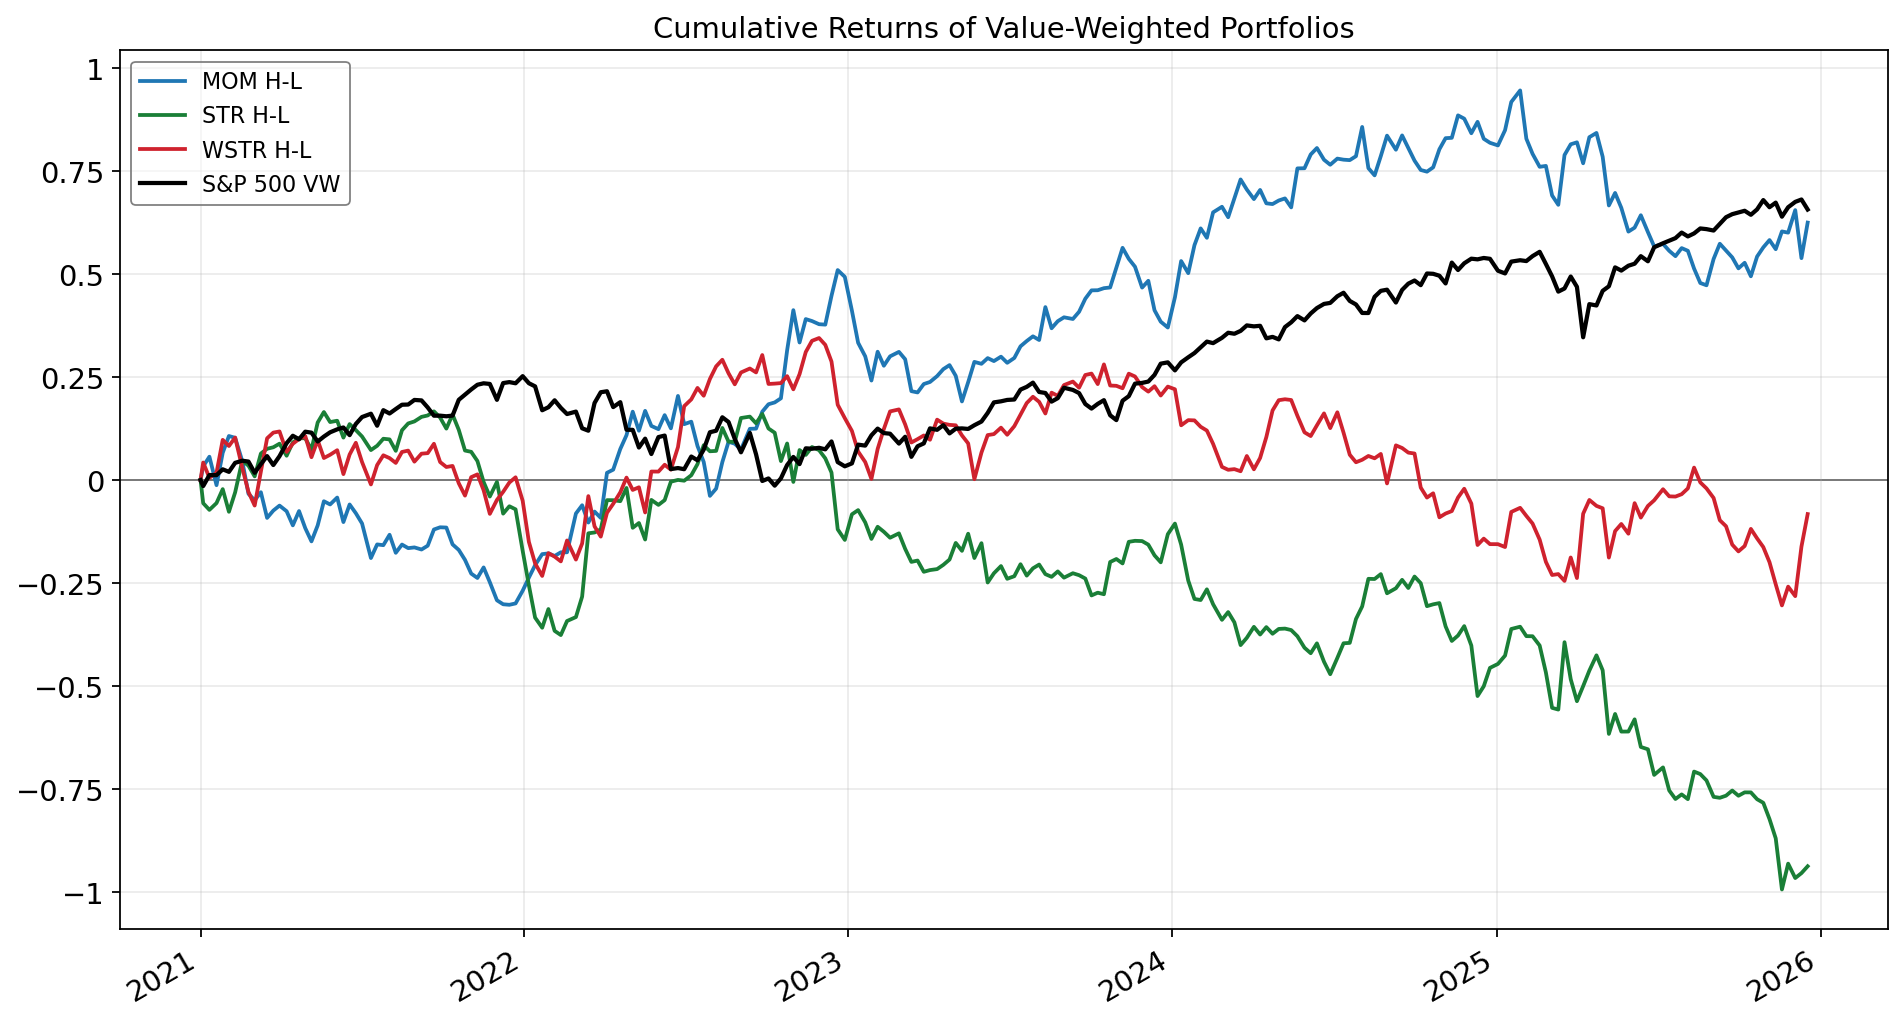

In [24]:
display(Image(str(OUT / "long_short_vw.png")))

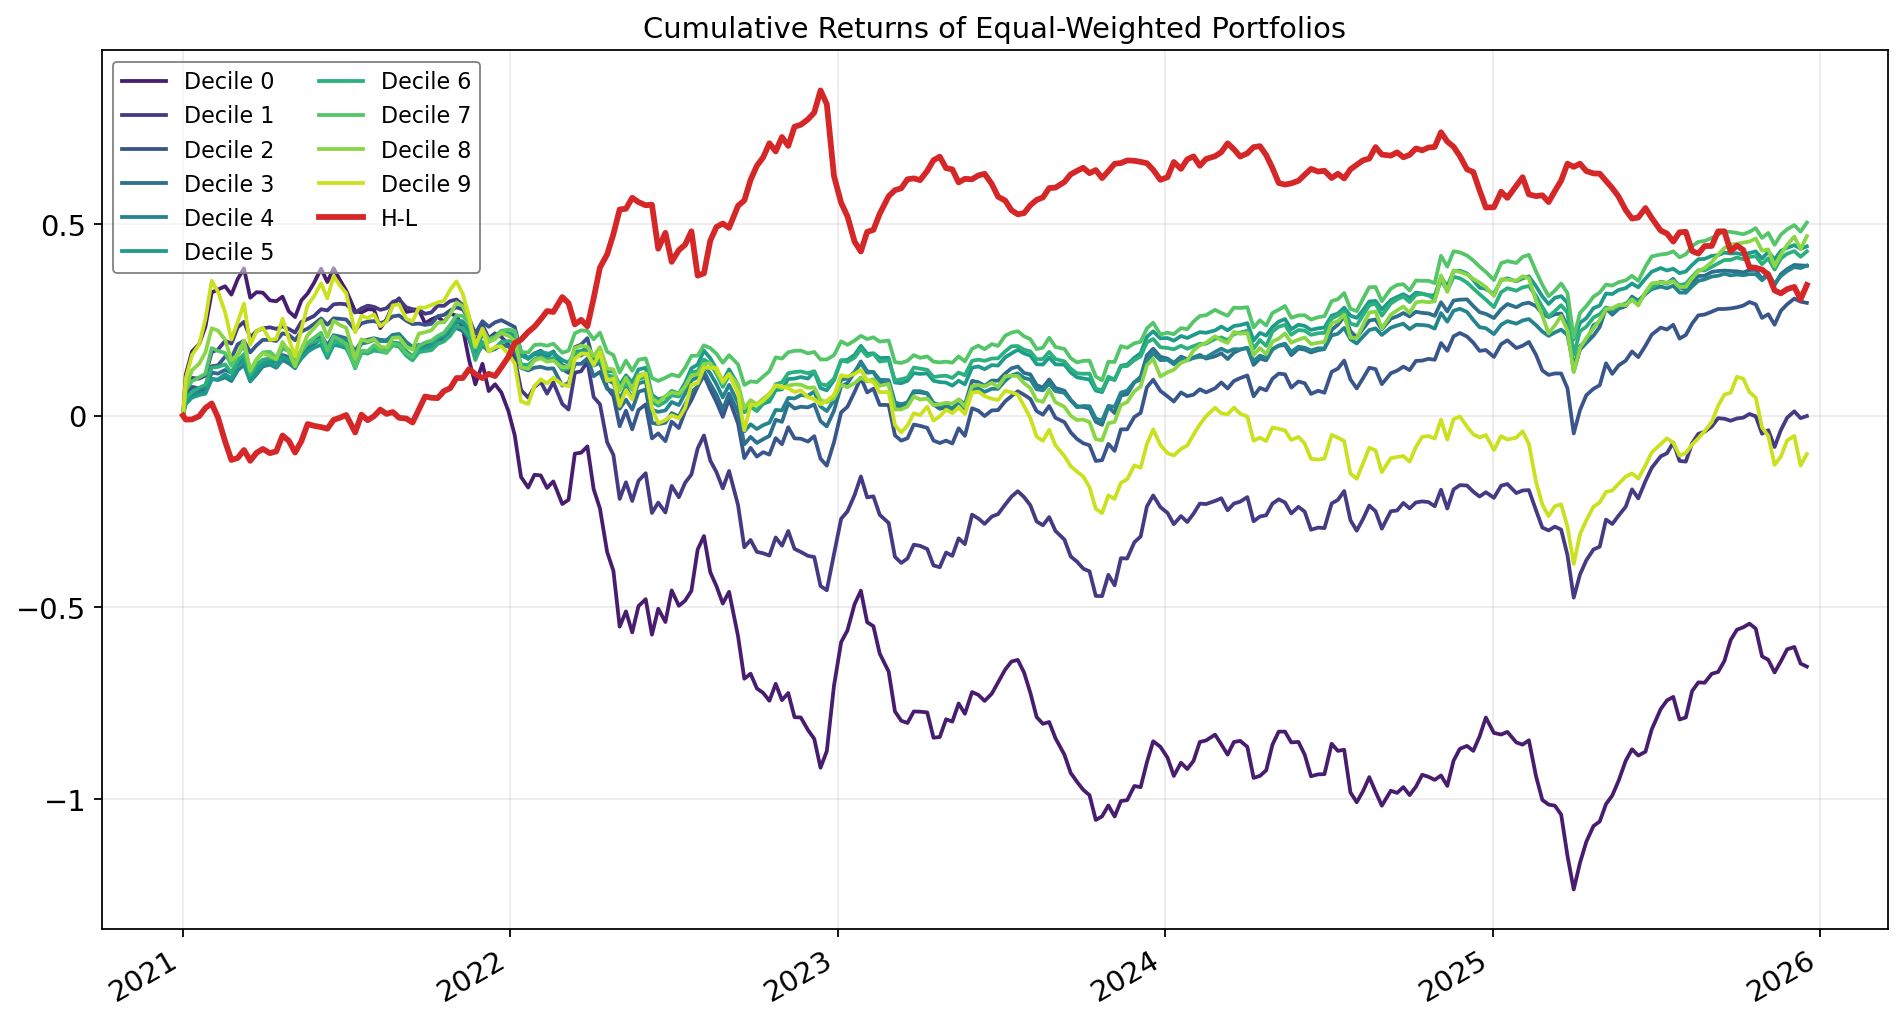

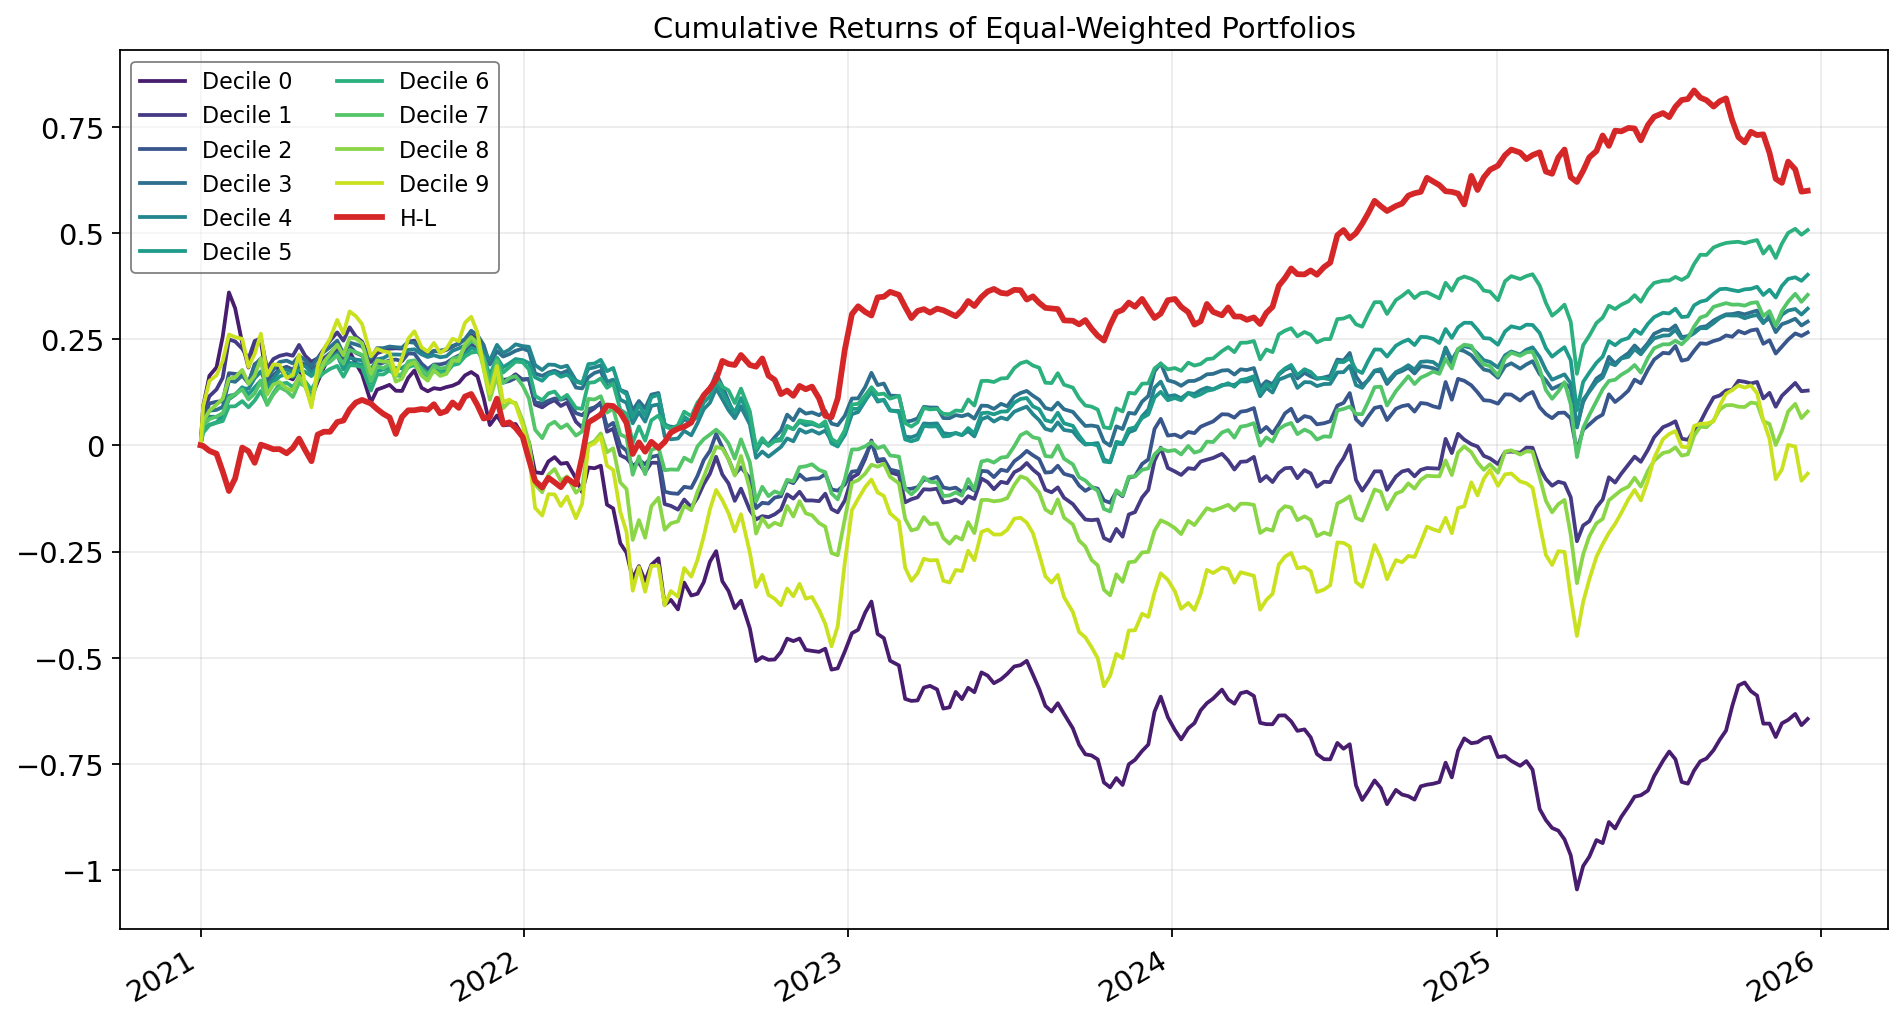

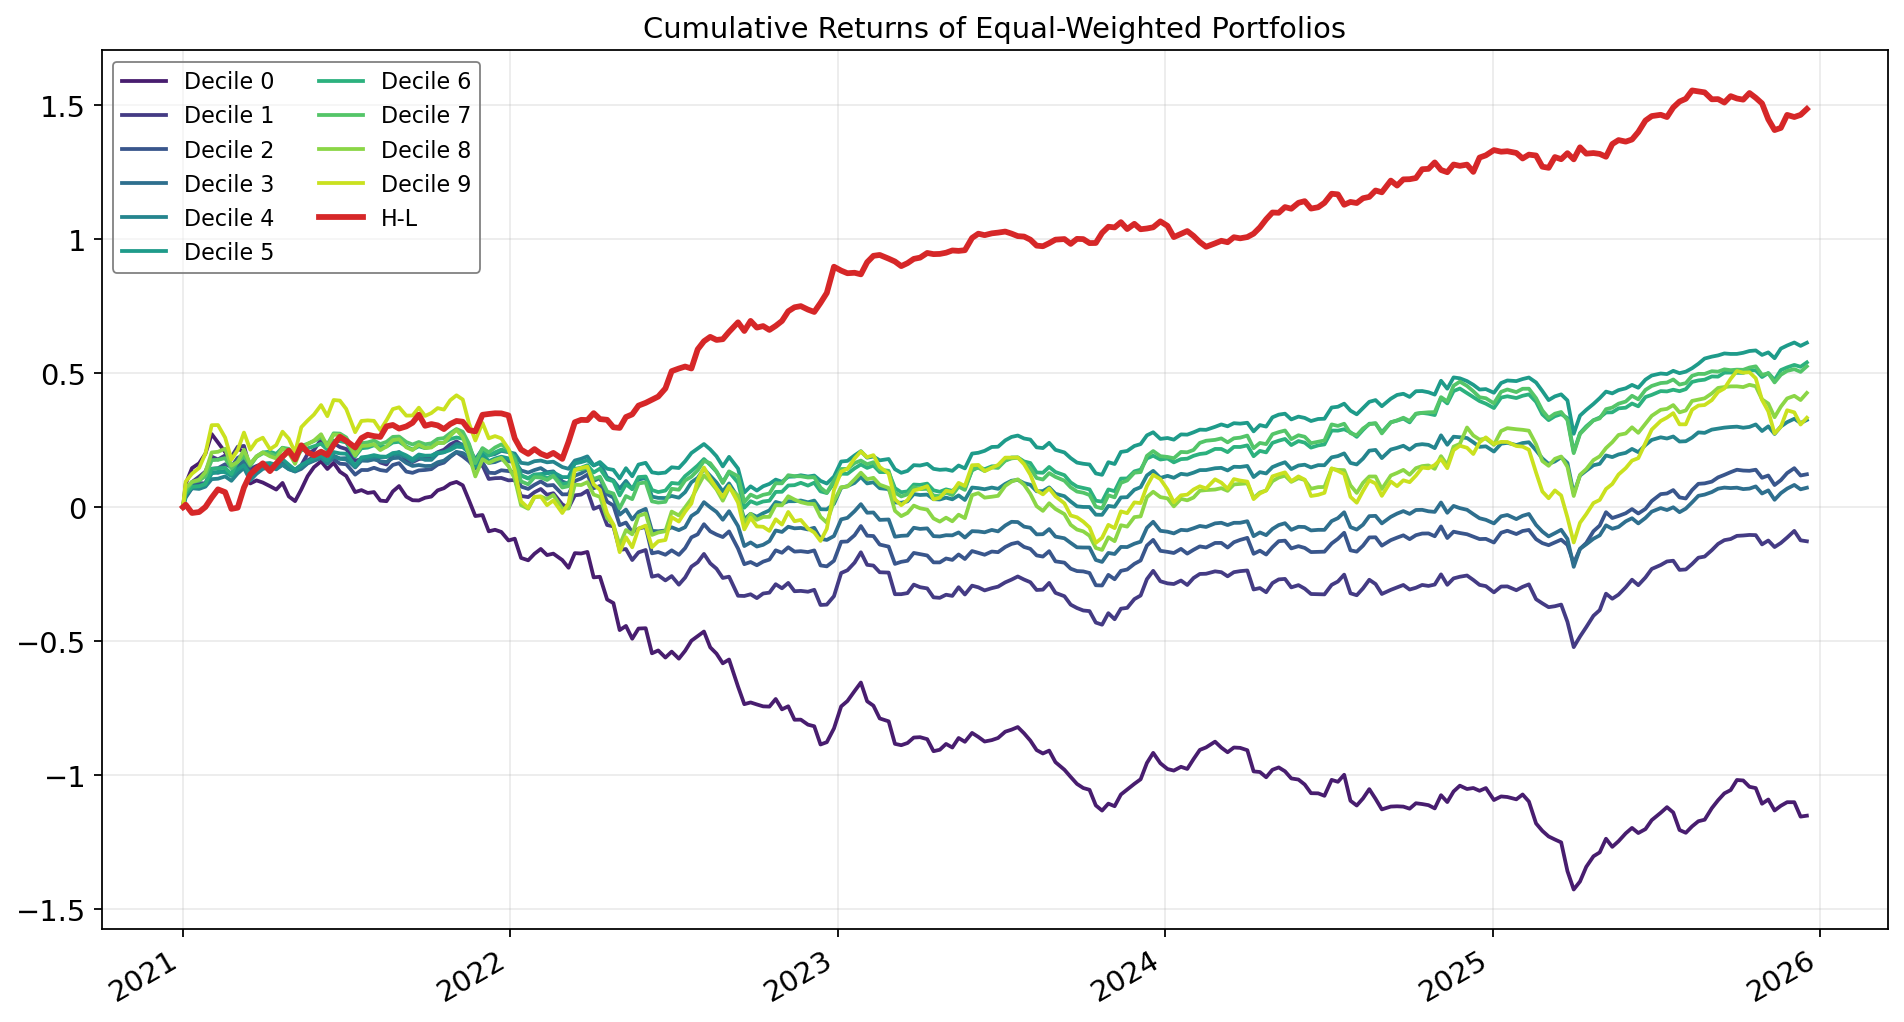

In [17]:
# 分位图：每路策略自己一张，看分位单调性
for name in ("mom", "str", "wstr"):
    display(Image(str(OUT / f"decile_spread_{name}_ew.png")))

## 7 用 S&P 500 做对比

包内不附带市场指数数据，图表也不会自行叠加基准线。下面两格调用的
`stockportfoliotoolkit.benchmark` 是仓库内保留的示例辅助模块，读的是
`src/stockportfoliotoolkit/data/` 下的序列——该序列不随 wheel 分发，
因此这两格只在仓库内可运行。

要让基准进入结果表与图表，走 `input.references`，见本节末尾。

In [18]:
from stockportfoliotoolkit.benchmark import benchmark_curve, benchmark_label, load_sp500_daily

bench = load_sp500_daily()
print(f"{len(bench)} 个交易日  "
      f"{bench['date'].min().date()} -> {bench['date'].max().date()}")
print("图例文案:", benchmark_label("EW"), "/", benchmark_label("VW"))
bench.head()

8561 个交易日  1992-01-02 -> 2025-12-31
图例文案: S&P 500 EW / S&P 500 VW


,date,ew_ret,vw_ret
0,1992-01-02,0.000610,0.000608
1,1992-01-03,0.006576,0.004580
2,1992-01-06,-0.000601,-0.002667
3,1992-01-07,0.000909,-0.001305
4,1992-01-08,0.007248,0.001831


In [19]:
# 回测区间内两个口径的基准净值，与上面 H-L 的 total_equity 直接可比
axis = result.analysis.curves["date"].drop_duplicates()
pd.DataFrame({
    "S&P 500 EW": benchmark_curve(axis, "EW").set_index("date")["equity"],
    "S&P 500 VW": benchmark_curve(axis, "VW").set_index("date")["equity"],
}).iloc[[0, -1]].round(4)

,S&P 500 EW,S&P 500 VW
date,,
2021-01-01,1.0000,1.0000
2025-12-17,1.6857,1.9278


### 走 `input.references` 把基准接进流水线

上面两格是手工叠图。要让基准进入结果表与图表，把序列声明成 `references`——
两列即可，日期与该日收益率，列名用 `column_map` 映射：

```json
// input.json
"references": [
  { "name": "SPX_EW", "path": "${SIG}/spx_ew.csv",
    "column_map": { "date": "date", "ret": "ret" }, "frequency": "daily" },
  { "name": "SPX_VW", "path": "${SIG}/spx_vw.csv",
    "column_map": { "date": "date", "ret": "ret" }, "frequency": "daily" }
]
```

基准行以 `bucket="REF"`、`signal_model=` 基准名进入结果表。要同时上图，还需把
`"REF"` 列入该图的 `buckets`——只声明 `references` 只会进表，不会出现在 PNG 上。

一条 `references` 会对**每个**加权方案各复制一行，因此等权与市值加权各配一条指数时，
按 `weights` 拆成两个图表配置，再用 `signals` 白名单挑对应的那条：

```json
// visualizer.json
"charts": [
  { "name": "long_short", "buckets": ["H-L", "REF"],
    "weights": ["EW"], "signals": ["MOM", "STR", "WSTR", "SPX_EW"] },
  { "name": "long_short", "buckets": ["H-L", "REF"],
    "weights": ["VW"], "signals": ["MOM", "STR", "WSTR", "SPX_VW"] }
]
```

`signals` 对策略信号与基准名同时生效，所以参与该图的三路策略必须一并列出。两个配置
同名且 `weights` 互不重叠，产出的 `long_short_ew.png` 与 `long_short_vw.png` 不会互相覆盖。

与手工叠图的口径差别：`references` 的日频序列按 `[锚点 + reference_lag,
锚点 + reference_lag + horizon)` 复利后对齐调仓日历，和组合走同一套周期化口径；
上面两格的 `benchmark_curve` 则是买入持有后按日期轴取样，与调仓节奏无关。


## 8 `horizon` 与 `holding_days`

`forward_return.horizon` 是全包唯一一处「一期有多长」的定义，必填。`holding_days` 不写就
继承它，只用于年化因子 `252 / holding_days`。写了但不等于 `horizon` 会告警——那意味着
收益的测量期和你声称的持有期不是同一件事。

`calendar.rebalance_freq` 也应当等于 `horizon`，否则相邻两期的持有窗口会重叠或留缺口，
逐期累乘出来的净值和最大回撤会失真。

In [20]:
import warnings

from stockportfoliotoolkit.config_schema import ConfigError, EngineConfig

try:
    EngineConfig.from_dict({"n_buckets": 10})
except ConfigError as exc:
    print("缺 horizon ->", exc)

print("\n继承      -> holding_days =",
      EngineConfig.from_dict({"forward_return": {"horizon": 12}}).holding_days)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    EngineConfig.from_dict({"holding_days": 21, "forward_return": {"horizon": 5}})
print("\n不一致    ->", caught[0].message)

缺 horizon -> engine.forward_return.horizon 为必填项：请写明前视收益的测量期长度（交易日）。holding_days 未单独指定时即继承该值。

继承      -> holding_days = 12

不一致    -> engine.holding_days=21 与 engine.forward_return.horizon=5 不一致：每期实现收益按 5 个交易日测量（基准同窗口口径），而年化因子按每年 252/21 期折算。两者不等意味着组合收益的测量期与声称的持有期不是同一件事，年化收益/波动/夏普会相应偏移；确属有意为之可忽略本条。


## 9 读一次数据，扫一遍参数

四个阶段可以单独驱动，`InputBundle` 复用起来不用重读面板。

In [21]:
%%time
from stockportfoliotoolkit import Analyzer, PortfolioEngine
from stockportfoliotoolkit.config_schema import AnalyzerConfig

acfg = AnalyzerConfig.from_file(CONFIGS / "analyzer.json")
engine_cfg = json.loads((CONFIGS / "engine.json").read_text())

rows = []
for n in (5, 10, 20):
    ecfg = EngineConfig.from_dict({**engine_cfg, "n_buckets": n})
    s = Analyzer(acfg).run(PortfolioEngine(ecfg).run(result.bundle)).summary
    hl = s[(s["bucket"] == "H-L") & (s["weight"] == "EW")]
    for _, r in hl.iterrows():
        rows.append({"n_buckets": n, "signal": r["signal_model"], "sharpe": r["sharpe"]})

pd.DataFrame(rows).pivot(index="signal", columns="n_buckets", values="sharpe").round(4)

CPU times: user 33.6 s, sys: 3.95 s, total: 37.6 s
Wall time: 37.5 s


n_buckets,5,10,20
signal,,,
MOM,0.4840,0.4288,0.0739
STR,0.4511,0.7377,1.0752
WSTR,1.4681,1.7950,2.1055


## 10 产物

`visualizer.output_dir` 留空时，产物写到**首路信号文件同级**的 `outputs/`——跟你的数据放
一起，不随进程当前工作目录漂移。图和表平铺在同一层，不再分子目录。

要写到别处就显式给 `output_dir`。单独用 `Visualizer(cfg)` 不走 `run_pipeline` 时没有
信号路径可做锚点，那时 `output_dir` 就是必填的。

In [22]:
print("信号文件与产物目录同级：")
for path in sorted(WORK.iterdir()):
    print(f"  {path.name}{'/' if path.is_dir() else ''}")

print(f"\n{OUT.name}/ 里平铺着：")
for path in sorted(result.outputs):
    print(f"  {path.relative_to(OUT)}  ({path.stat().st_size // 1024} KB)")

信号文件与产物目录同级：
  configs/
  outputs/
  signal_mom.feather
  signal_str.feather
  signal_wstr.feather

outputs/ 里平铺着：
  curves.feather  (590 KB)
  decile_spread_mom_ew.png  (381 KB)
  decile_spread_mom_vw.png  (440 KB)
  decile_spread_str_ew.png  (407 KB)
  decile_spread_str_vw.png  (412 KB)
  decile_spread_wstr_ew.png  (330 KB)
  decile_spread_wstr_vw.png  (469 KB)
  ic_by_period.csv  (29 KB)
  long_short_ew.png  (213 KB)
  long_short_vw.png  (230 KB)
  metrics_by_bucket.csv  (4 KB)
  summary_metrics.csv  (10 KB)


## 11 命令行

In [23]:
import sys

# spt 装在当前解释器旁边；notebook 的 shell 未必继承了这个 PATH
SPT = Path(sys.executable).parent / "spt"
!{SPT} run --config-dir {CONFIGS} --no-render

{
  "signals": {
    "MOM": {
      "rows": 1211662,
      "assets": 6786,
      "first": "2021-01-04",
      "last": "2025-12-24",
      "rows_on_calendar": 1211662,
      "source_rows": 1211662,
      "source_na_rate": 0.0
    },
    "STR": {
      "rows": 1320237,
      "assets": 7385,
      "first": "2021-01-04",
      "last": "2025-12-24",
      "rows_on_calendar": 1320237,
      "source_rows": 1320237,
      "source_na_rate": 0.0
    },
    "WSTR": {
      "rows": 1328053,
      "assets": 7449,
      "first": "2021-01-04",
      "last": "2025-12-24",
      "rows_on_calendar": 1328053,
      "source_rows": 1328053,
      "source_na_rate": 0.0
    }
  },
  "prices": {
    "rows": 6656698,
    "assets": 7449,
    "first": "2021-01-04",
    "last": "2025-12-31"
  },
  "references": [],
  "calendar": {
    "periods": 251,
    "first": "2021-01-04",
    "last": "2025-12-24",
    "rebalance_freq": 5,
    "native_stride": 5,
    "applied_stride": 1
  }
}

=== headline metrics ===
signal_

In [25]:
!{SPT} run --config-dir {CONFIGS} --no-render

{
  "signals": {
    "MOM": {
      "rows": 1211662,
      "assets": 6786,
      "first": "2021-01-04",
      "last": "2025-12-24",
      "rows_on_calendar": 1211662,
      "source_rows": 1211662,
      "source_na_rate": 0.0
    },
    "STR": {
      "rows": 1320237,
      "assets": 7385,
      "first": "2021-01-04",
      "last": "2025-12-24",
      "rows_on_calendar": 1320237,
      "source_rows": 1320237,
      "source_na_rate": 0.0
    },
    "WSTR": {
      "rows": 1328053,
      "assets": 7449,
      "first": "2021-01-04",
      "last": "2025-12-24",
      "rows_on_calendar": 1328053,
      "source_rows": 1328053,
      "source_na_rate": 0.0
    }
  },
  "prices": {
    "rows": 6656698,
    "assets": 7449,
    "first": "2021-01-04",
    "last": "2025-12-31"
  },
  "references": [],
  "calendar": {
    "periods": 251,
    "first": "2021-01-04",
    "last": "2025-12-24",
    "rebalance_freq": 5,
    "native_stride": 5,
    "applied_stride": 1
  }
}

=== headline metrics ===
signal_

# 下一步计划
* 调整benckmark
* 测试
* TestPyPI